Newton divided difference

Lagrange Interpolating Polynomial:
 2
x 


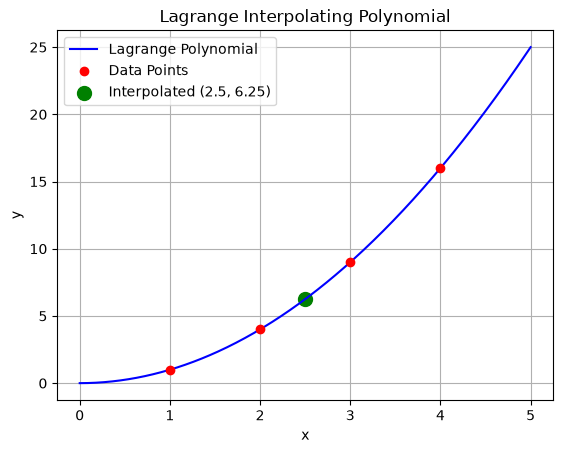


Interpolated value at x = 2.5: y = 6.25


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


def lagrange_interpolation(x_values, y_values):
    """
    Compute the Lagrange interpolating polynomial for given data points.

    Parameters:
    x_values : list or array : x-coordinates of data points
    y_values : list or array : y-coordinates of data points

    Returns:
    polynomial : sympy expression : The Lagrange polynomial
    """
    x = sp.Symbol('x')
    n = len(x_values)
    L = 0

    for i in range(n):
        term = y_values[i]
        for j in range(n):
            if i != j:
                term *= (x - x_values[j]) / (x_values[i] - x_values[j])
        L += term

    return sp.simplify(L)


def plot_lagrange(x_values, y_values, polynomial, x_interp=None):
    """
    Plot the Lagrange interpolating polynomial along with the data points and an interpolated value.

    Parameters:
    x_values : list or array : x-coordinates of data points
    y_values : list or array : y-coordinates of data points
    polynomial : sympy expression : The Lagrange polynomial
    x_interp : float (optional) : The x value at which to evaluate the polynomial
    """
    x = sp.Symbol('x')
    f_lambdified = sp.lambdify(x, polynomial, 'numpy')

    x_plot = np.linspace(min(x_values) - 1, max(x_values) + 1, 500)
    y_plot = f_lambdified(x_plot)

    plt.plot(x_plot, y_plot, label="Lagrange Polynomial", color='blue')
    plt.scatter(x_values, y_values, color='red', label="Data Points", zorder=3)

    if x_interp is not None:
        y_interp = f_lambdified(x_interp)
        plt.scatter([x_interp], [y_interp], color='green', marker='o', s=100,
                    label=f"Interpolated ({x_interp}, {y_interp:.2f})")

    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Lagrange Interpolating Polynomial')
    plt.legend()
    plt.grid(True)
    plt.show()

    return y_interp if x_interp is not None else None


# Example Usage
x_vals = [1, 2, 3, 4]
y_vals = [1, 4, 9, 16]

poly = lagrange_interpolation(x_vals, y_vals)
print("Lagrange Interpolating Polynomial:")
sp.pprint(poly)  # Pretty print the polynomial


# Define the point to interpolate
x_interp_val = 2.5
y_interp_val = plot_lagrange(x_vals, y_vals, poly, x_interp_val)

print(f"\nInterpolated value at x = {x_interp_val}: y = {y_interp_val:.2f}")

HERMITE INTERPOLATION


Interpolated value at x = 0.5: 0.47944687500000005


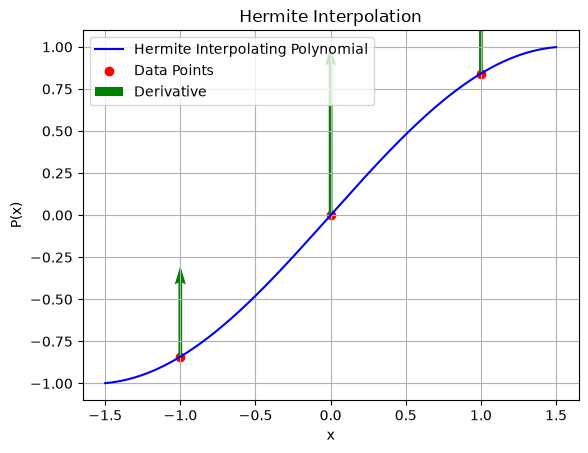

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import BarycentricInterpolator


def divided_differences(x, y, dy):
    n = len(x)
    Q = np.zeros((2*n, 2*n))
    Z = np.zeros(2*n)

    for i in range(n):
        Z[2*i] = Z[2*i + 1] = x[i]
        Q[2*i][0] = Q[2*i + 1][0] = y[i]
        Q[2*i + 1][1] = dy[i]
        if i > 0:
            Q[2*i][1] = (Q[2*i][0] - Q[2*i - 1][0]) / (Z[2*i] - Z[2*i - 1])

    for j in range(2, 2*n):
        for i in range(j, 2*n):
            Q[i][j] = (Q[i][j-1] - Q[i-1][j-1]) / (Z[i] - Z[i-j])

    return Z, Q


def hermite_interpolation(x, y, dy, xp):
    Z, Q = divided_differences(x, y, dy)

    # Compute polynomial value at xp
    n = len(Z)
    p = Q[0, 0]
    product_term = 1

    for i in range(1, n):
        product_term *= (xp - Z[i-1])
        p += Q[i, i] * product_term

    return p, Z, Q


def plot_hermite(x, y, dy):
    xp = np.linspace(min(x)-0.5, max(x)+0.5, 1000)
    yp = np.array([hermite_interpolation(x, y, dy, val)[0] for val in xp])

    plt.plot(xp, yp, label="Hermite Interpolating Polynomial", color='b')
    plt.scatter(x, y, color='r', label="Data Points")

    for i in range(len(x)):
        plt.quiver(x[i], y[i], 0, dy[i], angles='xy',
                   scale_units='xy', scale=1, color='g',
                   label="Derivative" if i == 0 else "")

    plt.legend()
    plt.xlabel("x")
    plt.ylabel("P(x)")
    plt.title("Hermite Interpolation")
    plt.grid()
    plt.show()


# Example-1 usage
# x = np.array([1.0, 2.0, 3.0])
# y = np.array([2.0, 3.0, 5.0])
# dy = np.array([1.0, 1.5, 2.0])


# Example-2 usage
x = np.array([-1, 0, 1])
y = np.array([-0.8415, 0, 0.8415])
dy = np.array([0.5403, 1, 0.5403])


# Example usage
# x = np.array([-1, 0, 1])
# y = np.array([0.5403, 1, 0.5403])
# dy = np.array([-0.8415, 0, 0.8415])

xp = .5  # Point to interpolate

interpolated_value, Z, Q = hermite_interpolation(x, y, dy, xp)
print(f"Interpolated value at x = {xp}: {interpolated_value}")

plot_hermite(x, y, dy)